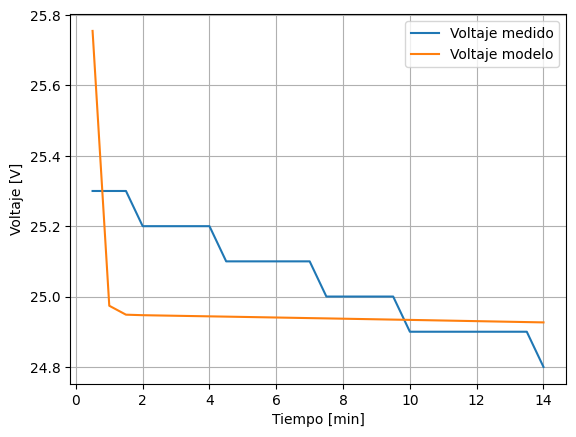

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Nombre del archivo
archivo = "dataset_bateria_combinado.xlsx"

# Leer la hoja principal
df = pd.read_excel(
    archivo,
    sheet_name="Dataset_Combinado",
    header=3
)

df = df.dropna(how="all")
df.columns = df.columns.str.strip()
df["Etapa"] = df["Etapa"].astype(str).str.strip()

# Separar descarga y carga
df_descarga = df[df["Etapa"].str.lower() == "descarga"].copy()
df_carga = df[df["Etapa"].str.lower() == "carga"].copy()

# Quedarse solo con filas completas
df_descarga = df_descarga[df_descarga["Datos completos"] == "Sí"].copy()
df_carga = df_carga[df_carga["Datos completos"] == "Sí"].copy()

df_descarga = df_descarga.reset_index(drop=True)
df_carga = df_carga.reset_index(drop=True)

# Parámetros
R = 0.001
E_0 = 25.3002
K = 0.345139
A = 0.80537
B = 74.829259
Q = 20

SOC = 1

for k in range(len(df_descarga)):

    P = df_descarga.loc[k, "Potencia con signo [W]"]

    it_k = Q * (1 - SOC)

    E_k = E_0 - K * Q / (Q - it_k) + A * np.exp(-B * it_k)

    discriminante = E_k**2 - 4 * R * P

    if discriminante < 0:
        print(f"Error en fila {k}: discriminante negativo")
        break

    i_k = (E_k - np.sqrt(discriminante)) / (2 * R)

    V_k = E_k - R * i_k

    dt = df_descarga.loc[k, "Δt [h]"]

    it_k_1 = it_k + i_k * dt

    SOC = 1 - it_k_1 / Q

    df_descarga.loc[k, "E_modelo [V]"] = E_k
    df_descarga.loc[k, "I_modelo [A]"] = i_k
    df_descarga.loc[k, "V_modelo [V]"] = V_k
    df_descarga.loc[k, "SOC"] = SOC
    df_descarga.loc[k, "it [Ah]"] = it_k_1

plt.figure()
plt.plot(df_descarga["Tiempo [min]"], df_descarga["Voltaje medido [V]"], label="Voltaje medido")
plt.plot(df_descarga["Tiempo [min]"], df_descarga["V_modelo [V]"], label="Voltaje modelo")
plt.xlabel("Tiempo [min]")
plt.ylabel("Voltaje [V]")
plt.legend()
plt.grid()
plt.show()

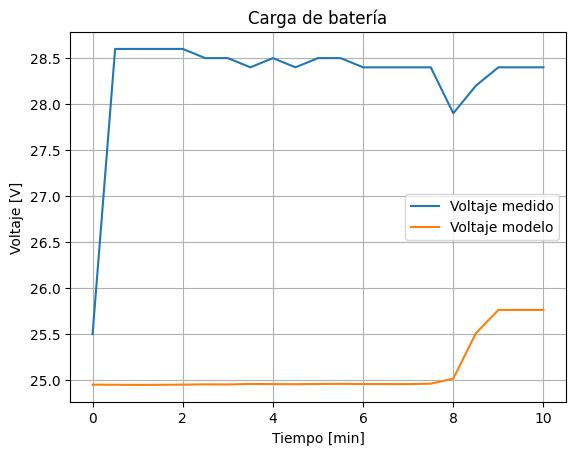

In [ ]:
SOC = df_descarga["SOC"].iloc[-1]

for k in range(len(df_carga)):

    P = -abs(df_carga.loc[k, "Potencia con signo [W]"])

    it_k = Q * (1 - SOC)

    it_k = min(max(it_k, 0), Q * 0.9999)

    E_k = E_0 - K * Q / (Q - it_k) + A * np.exp(-B * it_k)

    discriminante = E_k**2 - 4 * R * P

    if discriminante < 0:
        print(f"Error en fila {k}: discriminante negativo")
        break

    i_k = (E_k - np.sqrt(discriminante)) / (2 * R)

    V_k = E_k - R * i_k

    dt = df_carga.loc[k, "Δt [h]"]

    it_k_1 = it_k + i_k * dt

    it_k_1 = min(max(it_k_1, 0), Q)

    SOC = 1 - it_k_1 / Q
    df_carga.loc[k, "E_modelo [V]"] = E_k
    df_carga.loc[k, "I_modelo [A]"] = i_k
    df_carga.loc[k, "V_modelo [V]"] = V_k
    df_carga.loc[k, "SOC"] = SOC
    df_carga.loc[k, "it [Ah]"] = it_k_1


plt.figure()
plt.plot(df_carga["Tiempo [min]"], df_carga["Voltaje medido [V]"], label="Voltaje medido")
plt.plot(df_carga["Tiempo [min]"], df_carga["V_modelo [V]"], label="Voltaje modelo")
plt.xlabel("Tiempo [min]")
plt.ylabel("Voltaje [V]")
plt.title("Carga de batería")
plt.legend()
plt.grid()
plt.show()